# 02c — Euclidean pan (visual centering)

**Not a hyperbolic isometry.** This notebook subtracts the focus protein's orthographic disk coordinates from every scatter point and every geodesic polyline sample (rigid **Euclidean translation**). The Poincaré metric is normally written for the origin-centered unit disk, so after translation the plotted curves are the **same** hyperbolic geodesics as before, only **moved** in the plane—they are not expressed as geodesics in a standard centered chart anymore.

The dashed circle is **`|w + z_focus| = 1`** where `w = z - z_focus` (the translated original unit circle). Its **center is at `(-dx,-dy) = -z_focus`**, not at the origin—so the rim is **not** centered on the focus unless the focus was already at 0 in disk coords. The **focus is at plot coordinates `(0,0)`**; the last code cell uses **`VIEW_HALF`** so the axes show a **local window** around the focus (otherwise Matplotlib autoscale makes different foci look identical).

Use **`02d_disk_focus_mobius.ipynb`** for a true disk automorphism that sends the focus to the origin while keeping geodesics correct in the disk model.

Set **`FOCUS_NODE`** and **`SEED_NODES`** in the last code cell.

In [5]:
import os

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 100

import dmercator_io as dm

RUN_SUBDIR = "d2"
RUN_SUBDIR = os.environ.get("DMERCATOR_RUN", RUN_SUBDIR)
paths = dm.paths_for_run(RUN_SUBDIR)
_, df = dm.parse_inf_coord(paths["inf_coord"])
G = dm.load_edges_graph(paths["edge"])

xO, yO = dm.ortho_xy_disk(df)
pos_idx = {v: i for i, v in enumerate(df["Vertex"])}
print("RUN_SUBDIR:", RUN_SUBDIR, "|V|=", len(pos_idx), "|E|=", G.number_of_edges())

RUN_SUBDIR: d2 |V|= 17090 |E|= 298866


In [6]:
# Poincaré disk ↔ upper half-plane geodesics (orthographic disk z = x + iy)


def _disk_to_upper(z: complex) -> complex:
    return 1j * (1 + z) / (1 - z)


def _upper_to_disk(w):
    return (w - 1j) / (w + 1j)


def _halfplane_geodesic_points(u1: complex, u2: complex, n: int):
    u1 = complex(u1)
    u2 = complex(u2)
    if abs(u1 - u2) < 1e-14:
        return np.array([u1], dtype=np.complex128)
    if abs(u1.real - u2.real) < 1e-12 * (1.0 + abs(u1.imag) + abs(u2.imag)):
        im = np.linspace(u1.imag, u2.imag, n)
        return u1.real + 1j * im
    denom = 2.0 * (u2.real - u1.real)
    c = (abs(u2) ** 2 - abs(u1) ** 2) / denom + 0j
    r = float(abs(u1 - c))
    t1 = np.angle(u1 - c)
    t2 = np.angle(u2 - c)
    delta = (t2 - t1 + np.pi) % (2 * np.pi) - np.pi
    angles = t1 + np.linspace(0.0, float(delta), n)
    return c + r * np.exp(1j * angles)


def poincare_geodesic_xy(z1, z2, n: int = 48):
    z1 = complex(z1)
    z2 = complex(z2)
    u1 = _disk_to_upper(z1)
    u2 = _disk_to_upper(z2)
    pts_h = _halfplane_geodesic_points(u1, u2, n)
    pts_d = _upper_to_disk(pts_h)
    return pts_d.real, pts_d.imag

FOCUS_NODE: GRB2 edges: 411


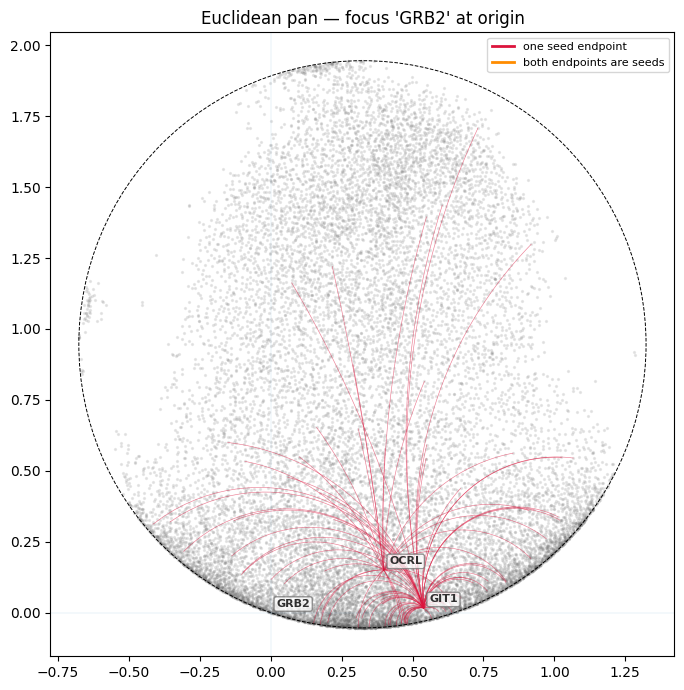

In [9]:
from matplotlib.lines import Line2D

FOCUS_NODE = "GRB2"  # Euclidean shift puts this vertex at (0, 0)
SEED_NODES = ["GRB2", "GIT1", "OCRL"]

if FOCUS_NODE.strip() not in pos_idx:
    raise ValueError(f"FOCUS_NODE not in graph/coords: {FOCUS_NODE!r}")
fj = pos_idx[FOCUS_NODE.strip()]
z_focus = complex(xO[fj], yO[fj])
dx, dy = z_focus.real, z_focus.imag

seeds_valid = [str(n).strip() for n in SEED_NODES if str(n).strip()]
missing = [n for n in seeds_valid if n not in pos_idx]
seeds_ok = [n for n in seeds_valid if n in pos_idx]
seed_set = set(seeds_ok)
if missing:
    print("Unknown seeds (skipped):", missing)
if not seeds_ok:
    raise ValueError("No valid SEED_NODES")

edge_rows = []
for a, b in G.edges():
    if a not in pos_idx or b not in pos_idx:
        continue
    a_in, b_in = a in seed_set, b in seed_set
    if not (a_in or b_in):
        continue
    edge_rows.append((a, b, a_in and b_in))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(xO - dx, yO - dy, s=2, alpha=0.12, c="0.4")
col_single = "crimson"
col_both = "darkorange"
for a, b, both in edge_rows:
    ia, ib = pos_idx[a], pos_idx[b]
    z1 = complex(xO[ia], yO[ia])
    z2 = complex(xO[ib], yO[ib])
    if abs(z1) >= 0.999 or abs(z2) >= 0.999:
        continue
    gx, gy = poincare_geodesic_xy(z1, z2, n=48)
    ax.plot(gx - dx, gy - dy, lw=0.45, alpha=0.55, color=col_both if both else col_single)

# After translation w = z - z_focus, the unit circle |z|=1 becomes |w + z_focus| = 1
ax.add_patch(plt.Circle((-dx, -dy), 1.0, fill=False, ls="--", lw=0.7))
ax.set_aspect("equal")
ax.axhline(0, lw=0.3, alpha=0.25)
ax.axvline(0, lw=0.3, alpha=0.25)
# Focus sits at (0,0). Without fixed limits, autoscale fits the whole translated cloud,
# so changing FOCUS_NODE only shifts ticks—the shape looks identical. Pin a local window:
VIEW_HALF = 0.55  # half-width of square view; increase to see more neighborhood
ax.set_xlim(-VIEW_HALF, VIEW_HALF)
ax.set_ylim(-VIEW_HALF, VIEW_HALF)
ax.set_title("Euclidean pan — focus " + repr(FOCUS_NODE.strip()) + " at origin (local view)")
ax.legend(
    handles=[
        Line2D([0], [0], color=col_single, lw=2, label="one seed endpoint"),
        Line2D([0], [0], color=col_both, lw=2, label="both endpoints are seeds"),
    ],
    loc="upper right",
    fontsize=8,
)
for name in seeds_ok:
    j = pos_idx[name]
    ax.annotate(
        name,
        (xO[j] - dx, yO[j] - dy),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color="0.1",
        alpha=0.9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.45", alpha=0.75),
    )
print("FOCUS_NODE:", FOCUS_NODE, "edges:", len(edge_rows))
plt.tight_layout()
plt.show()